# 위험중립형 백테스팅

> **목표:** "오를 때 충분히 벌고, 내릴 때 확실히 피한다"

---

## 전략 구조

| 레이어 | 내용 |
|--------|------|
| 국면 판별 | MA20/60/120 정렬 + ADX 추세강도 → 4국면 |
| 전략 스위칭 | UPTREND: 골든크로스 / SIDEWAYS: 볼린저밴드 / DOWNTREND: 현금 |
| 포지션 관리 | 분할 매수 3단계 + 분할 매도 3단계 |
| 포트폴리오 | 5개 섹터 대표 종목 × 모멘텀 비례 배분 |
| 최적화 | Walk-Forward (12개월 학습 / 6개월 검증), metric=calmar_ratio |

---

## 성과 평가 기준

| 평가 단계 | 벤치마크 | 이유 |
|-----------|----------|------|
| 단일 종목 | 해당 종목 B&H | 전략 자체 유효성 검증 |
| 멀티종목 포트폴리오 | **KOSPI 지수 (^KS11)** | 시장 전체 대비 운용 성과 측정 |

### 핵심 판정 (상대 기준 — vs KOSPI)
| 지표 | 기준 | 의미 |
|------|------|------|
| Alpha | ≥ 0 | 전략 CAGR ≥ KOSPI CAGR (시장 초과수익) |
| MDD 감소율 | > 0 | 전략 MDD < KOSPI MDD (하락 방어) |
| Calmar 개선 | > 0 | 위험조정 수익 향상 |

### 보조 지표 (절대 기준, 참고값)
| 지표 | 기준 |
|------|------|
| CAGR | 5~10% |
| MDD | -15% 이내 |
| Calmar | 0.5 이상 |
| Sortino | 1.0 이상 |
| Duration | 126일 이내 (참고) |

## 0. 환경 설정

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import vectorbt as vbt

# ── 위험중립형 설정 ───────────────────────────────────────────────────────────
from vbt_backtest.profiles import neutral

# ── 전략 ─────────────────────────────────────────────────────────────────────
from vbt_backtest.strategies.combined.ma_regime_strategy import (
    calc_regime, make_signals as regime_make_signals, REGIME_COLORS,
)
from vbt_backtest.strategies.combined.partial_auto_strategy import (
    make_signals as partial_make_signals,
    run_backtest as partial_run_backtest,
)

# ── 최적화 ────────────────────────────────────────────────────────────────────
from vbt_backtest.optimizer import walk_forward, ADX_PARAM_GRID, WF_TRAIN_MONTHS, WF_TEST_MONTHS

# ── 포트폴리오 ────────────────────────────────────────────────────────────────
from vbt_backtest.portfolio_backtest import (
    load_portfolio_data, build_size_df, add_cash_etf,
    run_portfolio_backtest, run_bh_portfolio, run_bh_single,
    walk_forward_portfolio,
)

# ── 성과지표 & 시각화 ─────────────────────────────────────────────────────────
from vbt_backtest.data.loader import load_kospi, load_cash_etf
from vbt_backtest.metrics import build_metrics_table, calc_metrics, calc_relative_metrics
from vbt_backtest.plots.strategy import plot_regime, plot_single_backtest
from vbt_backtest.plots.optimizer import plot_walkforward_comparison, plot_walkforward_portfolio_comparison
from vbt_backtest.plots.performance import (
    plot_equity_curves, plot_weight_heatmap,
    plot_contribution, plot_diversification, plot_yearly_returns,
    plot_mdd_comparison,
    plot_yearly_stock_etf,
)

print(f'수수료: {neutral.FEES:.2%} | 슬리피지: {neutral.SLIPPAGE:.2%}')
print(f'ADX 임계값: {neutral.ADX_THRESHOLD} | ADX 횡보: {neutral.ADX_SIDEWAYS}')
print(f'분할매수 비중: 1차={neutral.ENTRY1_SIZE:.0%} / 2차={neutral.ENTRY2_SIZE:.0%} / 횡보={neutral.ENTRY_RANGE_SIZE:.0%}')
print(f'분할매도 유지: 1차={neutral.EXIT1_SIZE:.0%} / 2차={neutral.EXIT2_SIZE:.0%}')

수수료: 0.15% | 슬리피지: 0.10%
ADX 임계값: 25.0 | ADX 횡보: 20.0
분할매수 비중: 1차=40% / 2차=70% / 횡보=30%
분할매도 유지: 1차=40% / 2차=10%


---
## 1. 데이터 로드

위험중립형 포트폴리오는 **5개 섹터 대표 종목**으로 구성한다.
단일 종목 집중의 변동성을 분산투자로 완화하는 것이 목적이다.

| 종목 | WICS 섹터 |
|------|-----------|
| 삼성전자 | IT (반도체) |
| SK하이닉스 | IT (메모리) |
| NAVER | 경기관련소비재 (인터넷) |
| 현대차 | 경기관련소비재 (자동차) |
| POSCO홀딩스 | 소재 (철강) |

In [2]:
TICKERS = {
    '삼성전자':    '005930.KS',
    'SK하이닉스':  '000660.KS',
    'NAVER':      '035420.KS',
    '현대차':      '005380.KS',
    'POSCO홀딩스': '005490.KS',
}
START = '2019-01-01'
END   = '2024-12-31'

data      = load_portfolio_data(TICKERS, START, END)
close_df  = data['close']
high_df   = data['high']
low_df    = data['low']
volume_df = data['volume']

NAMES = list(close_df.columns)  # 주식 종목명 (5개)
N     = len(NAMES)

# 벤치마크 & 현금 대체 ETF 로드
kospi    = load_kospi(START, END)
cash_etf = load_cash_etf(START, END)

print(f'기간: {close_df.index[0].date()} ~ {close_df.index[-1].date()}')
print(f'종목: {NAMES}')
print(f'KOSPI: {len(kospi)}거래일 | 단기채ETF: {len(cash_etf)}거래일')
close_df.tail(3)

기간: 2019-01-02 ~ 2024-12-30
종목: ['삼성전자', 'SK하이닉스', 'NAVER', '현대차', 'POSCO홀딩스']
KOSPI: 1475거래일 | 단기채ETF: 1450거래일


Ticker,삼성전자,SK하이닉스,NAVER,현대차,POSCO홀딩스
Date,,,,,
2024-12-26,52005.328125,168028.703125,196856.390625,203067.671875,245475.078125
2024-12-27,52457.617188,172375.125000,194689.875000,200733.546875,243077.843750
2024-12-30,51969.183594,171782.421875,195871.609375,197932.625000,243077.843750


---
## 2. 단일 종목 — 시장 국면 판별

삼성전자를 예시로 4국면 판별 결과를 확인한다.

**판별 우선순위:** SIDEWAYS → UPTREND → DOWNTREND → TRANSITION

```
SIDEWAYS   : ADX < adx_sideways
UPTREND    : MA20 > MA60 > MA120  AND  ADX > adx_threshold
DOWNTREND  : MA20 < MA60 < MA120  AND  ADX > adx_threshold
TRANSITION : 위 3가지 미해당
```

In [3]:
name  = '삼성전자'
close = close_df[name]
high  = high_df[name]
low   = low_df[name]

regime, masks, adx_df = calc_regime(
    close, high, low,
    adx_threshold=neutral.ADX_THRESHOLD,
    adx_sideways=neutral.ADX_SIDEWAYS,
)

print('=== 국면별 거래일 수 ===')
counts = regime.value_counts()
total  = len(regime.dropna())
for r, c in counts.items():
    print(f'  {r:12s}: {c:4d}일  ({c/total:.1%})')

=== 국면별 거래일 수 ===
  SIDEWAYS    :  683일  (46.3%)
  TRANSITION  :  432일  (29.3%)
  UPTREND     :  259일  (17.6%)
  DOWNTREND   :  101일  (6.8%)


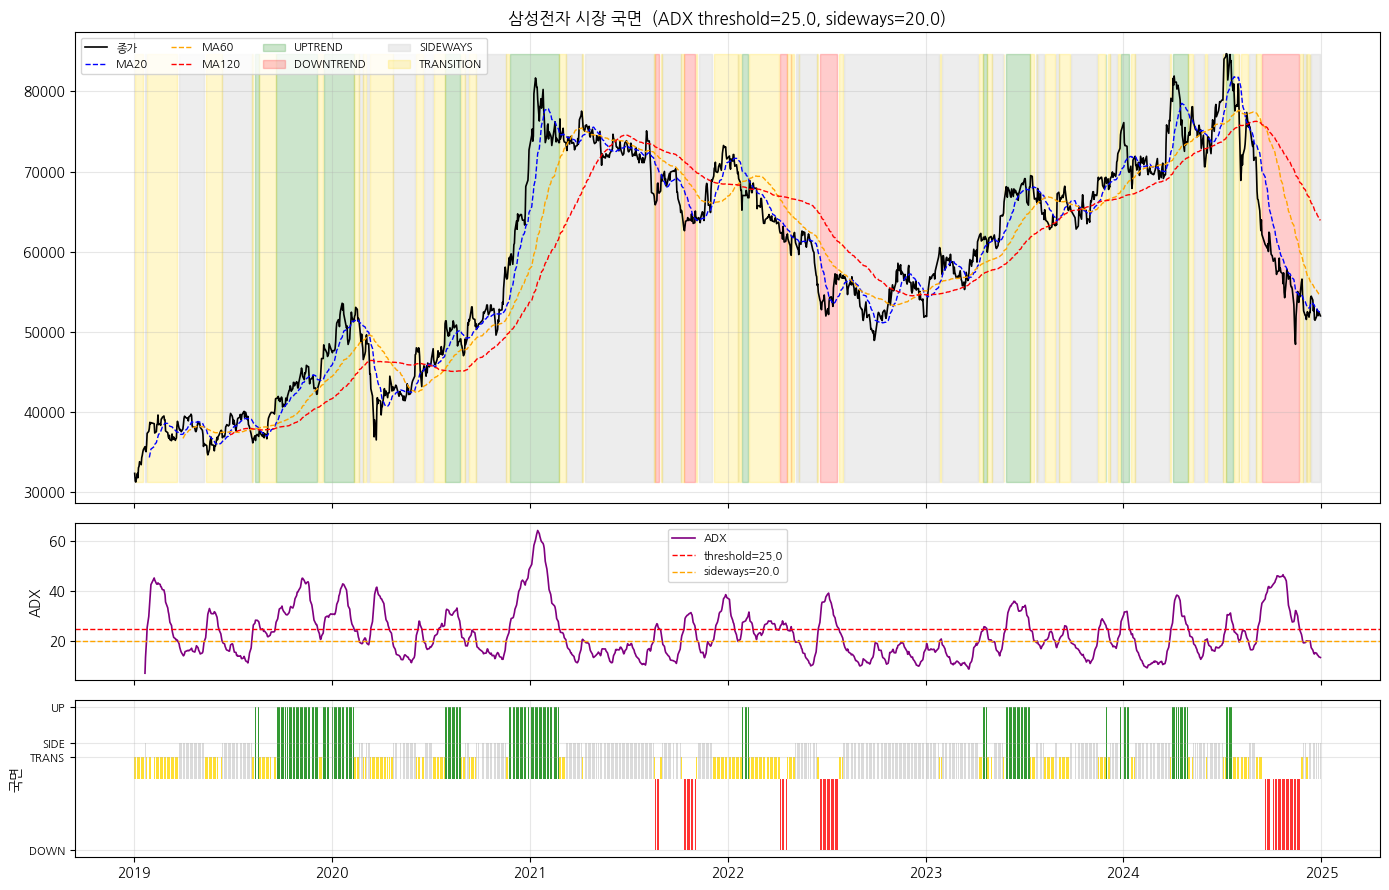

In [4]:
plot_regime(close, regime, masks, name,
            adx_threshold=neutral.ADX_THRESHOLD,
            adx_sideways=neutral.ADX_SIDEWAYS)

---
## 3. 단일 종목 — 분할 매수/매도 신호

**분할 매수 3단계:**

| 단계 | 조건 | 목표 비중 |
|------|------|-----------|
| 1차 | UPTREND + 골든크로스 | 40% |
| 2차 | UPTREND + MA20 지지 재확인 (60일 이내) | 70% |
| 횡보 | SIDEWAYS + 볼린저밴드 하단 | 30% |

**분할 매도 3단계 (청산 우선순위: DOWNTREND > 데드크로스 > TRANSITION > BB상단):**

| 단계 | 조건 | 유지 비중 |
|------|------|-----------|
| 1차 익절 | UPTREND → TRANSITION 전환 첫날 | 40% |
| 2차 청산 | 데드크로스 | 10% |
| 전량 청산 | DOWNTREND 진입 | 0% |

In [5]:
entries, exits, size_series, detail = partial_make_signals(
    close, high, low,
    adx_threshold=neutral.ADX_THRESHOLD,
    adx_sideways=neutral.ADX_SIDEWAYS,
    entry1_size=neutral.ENTRY1_SIZE,
    entry2_size=neutral.ENTRY2_SIZE,
    entry_range_size=neutral.ENTRY_RANGE_SIZE,
    exit1_size=neutral.EXIT1_SIZE,
    exit2_size=neutral.EXIT2_SIZE,
    recent_window=neutral.RECENT_WINDOW,
)

print('=== 신호 횟수 ===')
print(f'  1차 매수 (골든크로스):     {detail["entry1"].sum():3d}회')
print(f'  2차 매수 (MA20 지지):      {detail["entry2"].sum():3d}회')
print(f'  횡보 매수 (BB 하단):       {detail["entry_range"].sum():3d}회')
print(f'  1차 익절 (TRANSITION):     {detail["transition_from_up"].sum():3d}회')
print(f'  2차 청산 (데드크로스):     {detail["dead_cross"].sum():3d}회')
print(f'  횡보 청산 (BB 상단):       {detail["bb_exit_sideways"].sum():3d}회')

=== 신호 횟수 ===
  1차 매수 (골든크로스):       1회
  2차 매수 (MA20 지지):        4회
  횡보 매수 (BB 하단):         8회
  1차 익절 (TRANSITION):      12회
  2차 청산 (데드크로스):      15회
  횡보 청산 (BB 상단):        13회


---
## 4. 단일 종목 — 백테스트 성과

In [6]:
pf_single    = partial_run_backtest(
    close, high, low,
    adx_threshold=neutral.ADX_THRESHOLD,
    adx_sideways=neutral.ADX_SIDEWAYS,
    fees=neutral.FEES, slippage=neutral.SLIPPAGE,
)
pf_bh_single = run_bh_single(close, fees=neutral.FEES, slippage=neutral.SLIPPAGE)

n_years   = (close.index[-1] - close.index[0]).days / 365.25
row_strat = calc_metrics(pf_single.value(),    f'{name} 위험중립형', n_years)
row_bh    = calc_metrics(pf_bh_single.value(), f'{name} Buy&Hold',  n_years)
df_abs    = pd.DataFrame([row_bh, row_strat]).set_index('전략')
print('=== 절대 성과 ===')
display(df_abs)

# 벤치마크(B&H) 대비 상대 지표
rel = calc_relative_metrics(pf_single.value(), pf_bh_single.value(), f'{name} 위험중립형')
print(f'\n=== 상대 성과 (vs {name} B&H) ===')
for k, v in rel.items():
    if k != '전략':
        print(f'  {k:15s}: {v}')

=== 절대 성과 ===


,총 수익률,CAGR,연간 변동성,샤프비율,MDD,Calmar
전략,,,,,,
삼성전자 Buy&Hold,60.51%,8.22%,26.27%,0.44,-42.85%,0.19
삼성전자 위험중립형,18.66%,2.90%,6.33%,0.49,-10.39%,0.28



=== 상대 성과 (vs 삼성전자 B&H) ===
  Alpha(연환산)     : -5.45%
  Beta           : 0.16
  IR             : -0.37
  MDD감소율         : -75.75%
  Calmar개선       : +0.09
  Sortino개선      : -0.22


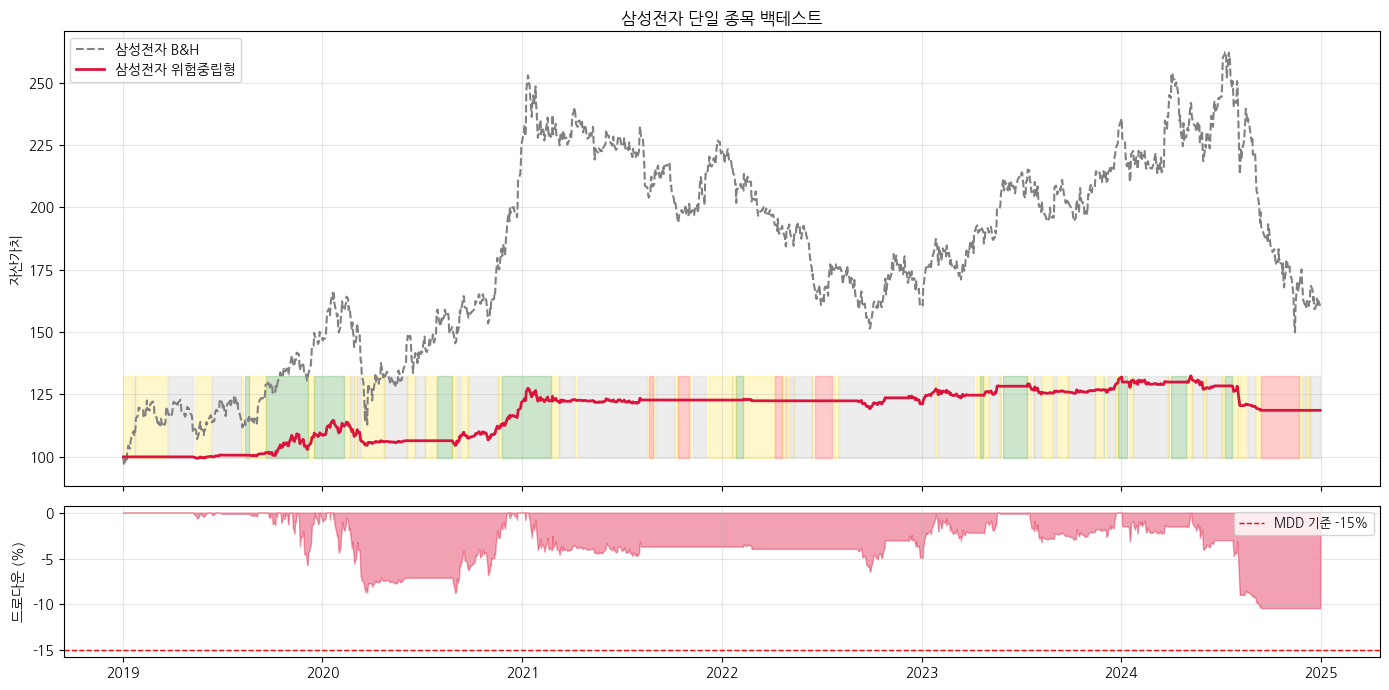

In [7]:
plot_single_backtest(pf_single, pf_bh_single, close, regime, name)

---
## 5. Walk-Forward 최적화

그리드 서치는 과거 데이터에 과최적화될 위험이 있다.
Walk-Forward는 **미래 데이터를 학습에 사용하지 않고** 6개월마다 파라미터를 재탐색한다.

```
[12개월 학습] → 최적 adx_threshold 탐색
                    ↓
            [6개월 검증] → 해당 파라미터로 실전 시뮬레이션
                                ↓
                        [다음 12개월 학습] → 재탐색 ...
```

**최적화 metric:** `calmar_ratio` (위험중립형 = MDD 최소화 목표)

In [8]:
print(f'탐색 범위: {ADX_PARAM_GRID}')
print(f'학습 구간: {WF_TRAIN_MONTHS}개월 / 검증 구간: {WF_TEST_MONTHS}개월')
print('최적화 기준: calmar_ratio (위험중립형 권장)')

탐색 범위: {'adx_threshold': [15, 20, 25, 30], 'adx_sideways': [10, 15, 20]}
학습 구간: 12개월 / 검증 구간: 6개월
최적화 기준: calmar_ratio (위험중립형 권장)


In [9]:
wf_result = walk_forward(
    close, partial_run_backtest,
    param_grid=ADX_PARAM_GRID,
    train_months=WF_TRAIN_MONTHS,
    test_months=WF_TEST_MONTHS,
    metric='calmar_ratio',
    fees=neutral.FEES,
    slippage=neutral.SLIPPAGE,
    high=high, low=low,
)

print(f'총 윈도우 수: {wf_result["n_windows"]}')
print()
print(f'{"학습 기간":^25} {"검증 기간":^25} {"최적 파라미터":^35} {"점수":>8}')
print('-' * 100)
for w in wf_result['windows']:
    train = f"{w['train_start'].date()} ~ {w['train_end'].date()}"
    test  = f"{w['test_start'].date()} ~ {w['test_end'].date()}"
    print(f'{train:^25} {test:^25} {str(w["best_params"]):^35} {w["best_score"]:>8.3f}')

총 윈도우 수: 9

          학습 기간                     검증 기간                         최적 파라미터                     점수
----------------------------------------------------------------------------------------------------
 2019-01-02 ~ 2020-01-02   2020-01-02 ~ 2020-07-01  {'adx_threshold': 30, 'adx_sideways': 20}    4.501
 2019-07-02 ~ 2020-07-02   2020-07-02 ~ 2020-12-30  {'adx_threshold': 15, 'adx_sideways': 10}   -0.285
 2020-01-02 ~ 2021-01-02   2021-01-04 ~ 2021-07-01  {'adx_threshold': 30, 'adx_sideways': 10}   10.145
 2020-07-02 ~ 2021-07-02   2021-07-02 ~ 2021-12-30  {'adx_threshold': 15, 'adx_sideways': 20}    4.591
 2021-01-02 ~ 2022-01-02   2022-01-04 ~ 2022-07-01  {'adx_threshold': 15, 'adx_sideways': 10}    1.378
 2021-07-02 ~ 2022-07-02   2022-07-04 ~ 2022-12-29  {'adx_threshold': 15, 'adx_sideways': 10}   -0.684
 2022-01-02 ~ 2023-01-02   2023-01-02 ~ 2023-06-30  {'adx_threshold': 20, 'adx_sideways': 10}   -0.252
 2022-07-02 ~ 2023-07-02   2023-07-03 ~ 2023-12-28  {'adx_threshold':

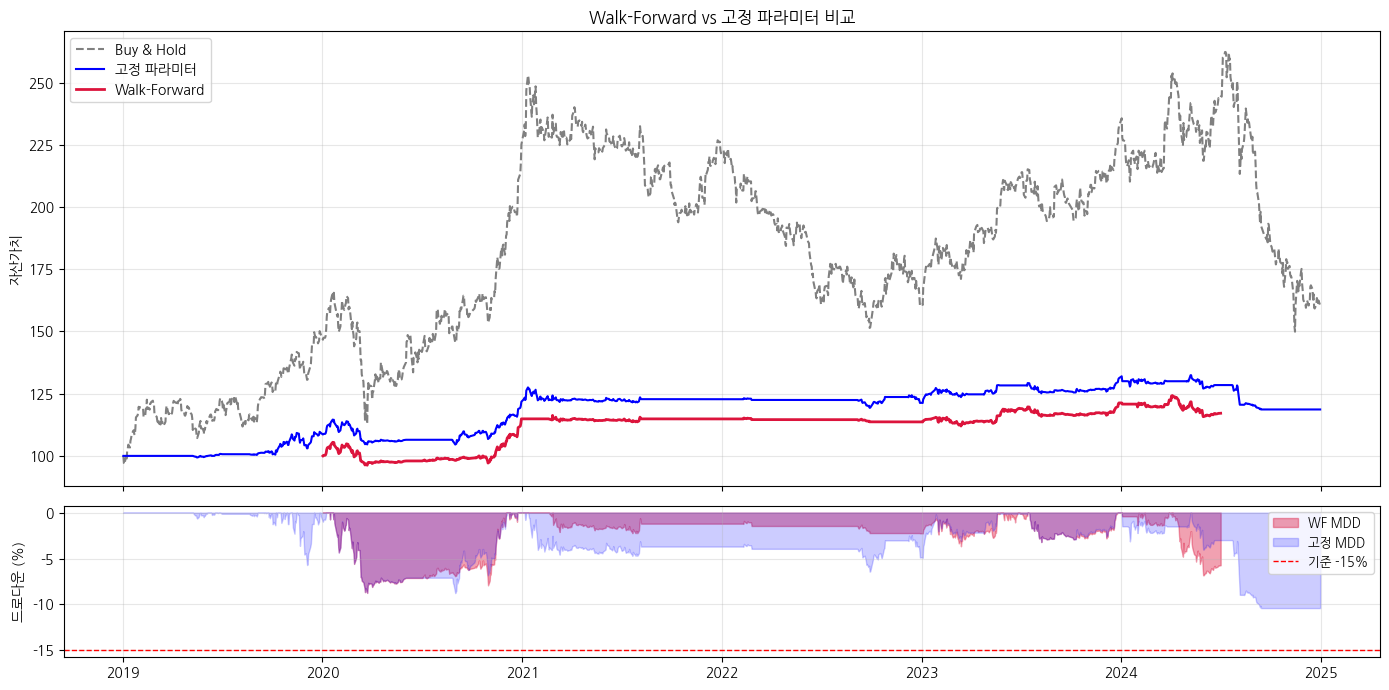

In [10]:
plot_walkforward_comparison(wf_result, pf_single, pf_bh_single)

---
## 6. 멀티종목 포트폴리오 (Walk-Forward 최적화 적용)

5개 종목에 Walk-Forward 최적화를 적용한다.  
12개월 학습 → 6개월 적용 슬라이딩으로 ADX 파라미터를 구간마다 재탐색하고,  
검증 구간의 매매 신호를 이어붙여 **단일 포트폴리오**로 운용한다.

| 항목 | 설명 |
|------|------|
| 최적화 기준 | `calmar_ratio` (MDD 최소화 + 수익 균형) |
| 탐색 범위 | adx_threshold: [15,20,25,30] × adx_sideways: [10,15,20] = 12조합 |
| 포지션 배분 | 국면별 모멘텀 비례 (UPTREND 126일 / TRANSITION 63일 / SIDEWAYS 21일) |

In [11]:
pf_port, wf_info = walk_forward_portfolio(
    close_df, high_df, low_df, volume_df,
    param_grid=ADX_PARAM_GRID,
    train_months=WF_TRAIN_MONTHS,
    test_months=WF_TEST_MONTHS,
    metric='calmar_ratio',
    min_momentum=neutral.MIN_MOMENTUM,
    kospi=kospi,
    kospi_ma=neutral.KOSPI_MA,
    atr_multiplier=neutral.ATR_MULTIPLIER,
    atr_period=neutral.ATR_PERIOD,
    fees=neutral.FEES,
    slippage=neutral.SLIPPAGE,
    cash_etf=cash_etf,
)

close_df_all = wf_info['close_df_all']
NAMES_ALL    = wf_info['names_all']   # 주식 5개 + 단기채 1개

# B&H 비교: pf_port와 동일한 기간에서 시작
port_start = pf_port.value().index[0]
pf_bh_eq = run_bh_portfolio(
    close_df.loc[close_df.index >= port_start],
    fees=neutral.FEES, slippage=neutral.SLIPPAGE,
)

print(f'총 윈도우 수: {wf_info["n_windows"]}')
print(f'포트폴리오 기간: {port_start.date()} ~ {pf_port.value().index[-1].date()}')
print()
print(f'{"검증 구간":^27} {"adx_threshold":^15} {"adx_sideways":^13} {"학습 score":>10}')
print('-' * 72)
for w in wf_info['windows']:
    p = w['best_params']
    s = w['best_score']
    score_str = f'{s:.3f}' if isinstance(s, float) and not pd.isna(s) else 'N/A'
    print(f'  {w["test_start"].date()} ~ {w["test_end"].date()}   '
          f'{p.get("adx_threshold", "-"):^13}   {p.get("adx_sideways", "-"):^11}   {score_str:>10}')

총 윈도우 수: 9
포트폴리오 기간: 2020-01-02 ~ 2024-12-30

           검증 구간             adx_threshold  adx_sideways    학습 score
------------------------------------------------------------------------
  2020-01-02 ~ 2020-07-01        30             10             3.841
  2020-07-02 ~ 2020-12-30        20             10             0.530
  2021-01-04 ~ 2021-07-01        20             15             7.640
  2021-07-02 ~ 2021-12-30        15             10             1.707
  2022-01-04 ~ 2022-07-01        25             15            -0.253
  2022-07-04 ~ 2022-12-29        15             20            -0.031
  2023-01-02 ~ 2023-06-30        15             20            -0.541
  2023-07-03 ~ 2023-12-28        20             10             4.343
  2024-01-02 ~ 2024-07-01        15             20             4.034


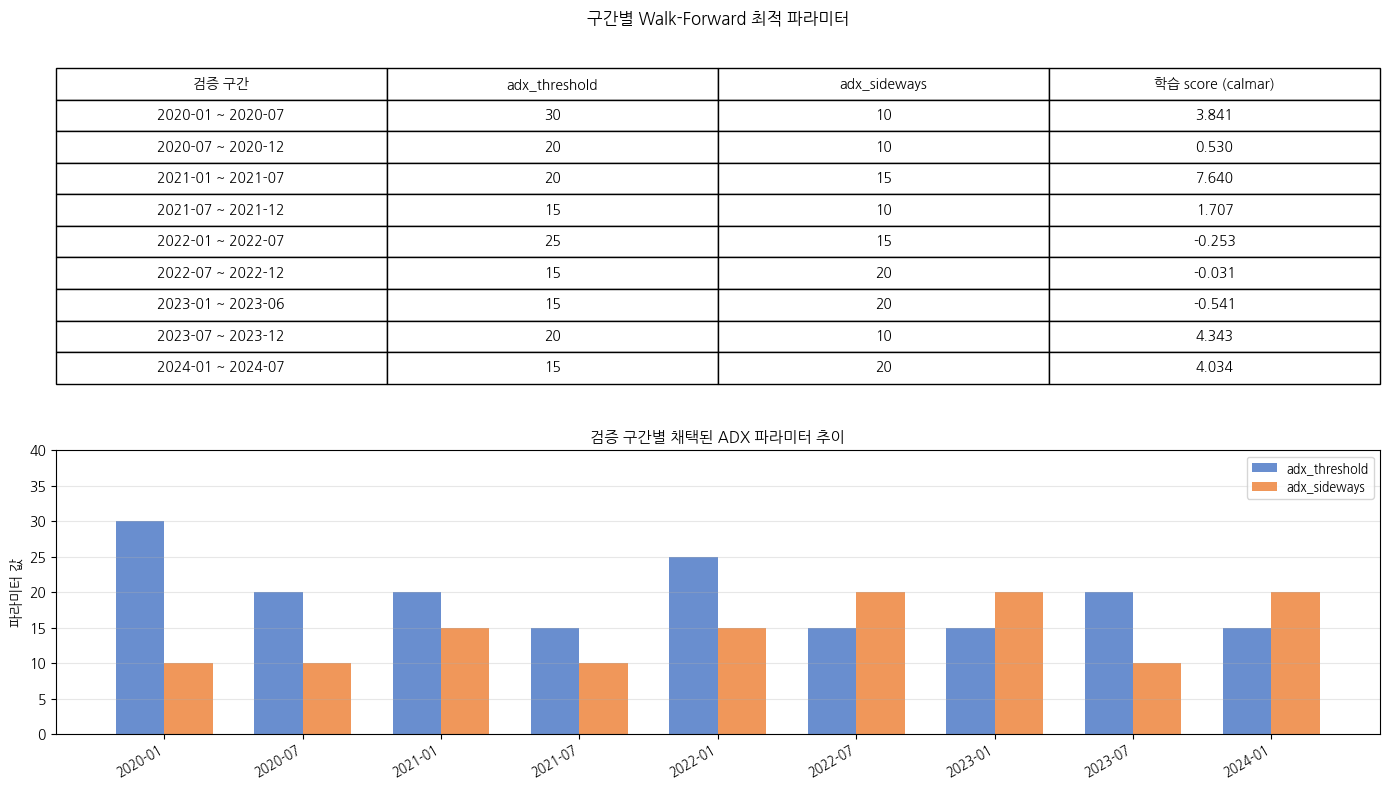

In [12]:
plot_walkforward_portfolio_comparison(wf_info, kospi=kospi)

In [13]:
plot_walkforward_portfolio_comparison(wf_port_result, pf_port, pf_bh_eq, kospi=kospi)

NameError: name 'wf_port_result' is not defined

---
## 7. 성과 평가

### 7-1. 성과 비교 테이블

### 7-2. MDD Depth + Duration 통합 비교

MDD Duration은 **단독으로 절대 기준을 적용하면 오해가 생긴다.**
낙폭(depth)이 작으면 Duration이 길어도 실전 자동매매 유지가 더 쉽다.

| 케이스 | MDD | Duration | 실전 운용 |
|--------|-----|----------|---------|
| A | -40% | 6개월 | ❌ 낙폭이 커서 심리적 포기 가능성 높음 |
| B | -10% | 18개월 | ✅ 낙폭이 작아 자동매매 유지 가능 |

**2019~2024 기간은 코로나(2020) + 금리인상(2022) 두 번의 구조적 약세장이 포함돼
모든 전략이 Duration 절대 기준을 초과한다.**

→ **핵심 판단: 위험중립형이 B&H 대비 MDD depth를 얼마나 줄였는가**

In [ ]:
# Cell 25, 27에서 재사용하는 공통 변수/함수 정의
def calc_mdd(equity: pd.Series) -> float:
    return (equity / equity.cummax() - 1).min()

def calc_mdd_duration(equity: pd.Series) -> int:
    in_dd = (equity / equity.cummax() - 1) < 0
    max_dur = current = 0
    for d in in_dd:
        current = current + 1 if d else 0
        max_dur = max(max_dur, current)
    return max_dur

kospi_eq = kospi.reindex(pf_port.value().index, method='ffill').dropna()
kospi_eq = kospi_eq / kospi_eq.iloc[0] * pf_port.value().iloc[0]

targets = {
    'KOSPI (벤치마크)':  kospi_eq,
    f'{N}종목 균등 B&H': pf_bh_eq.value(),
    '★ 위험중립형 포트': pf_port.value(),
}

plot_mdd_comparison(pf_port, pf_bh_eq, kospi, N)

### 7-3. Sortino 비율 · 하락 변동성 기준 효율

위험중립형 기준: **1.0 이상** (샤프비율 대체 지표)

In [ ]:
def _eval_strategy(eq: pd.Series, bm: pd.Series, label: str, n_years: float) -> None:
    """단일 전략의 핵심 판정 + 보조 지표 출력"""
    cagr    = (eq.iloc[-1] / eq.iloc[0]) ** (1 / n_years) - 1
    mdd     = calc_mdd(eq)
    calmar  = cagr / abs(mdd) if mdd < 0 else float('nan')
    sortino = calc_sortino(eq)
    dur     = calc_mdd_duration(eq)

    bm_cagr   = (bm.iloc[-1] / bm.iloc[0]) ** (1 / n_years) - 1
    bm_mdd    = calc_mdd(bm)
    bm_calmar = bm_cagr / abs(bm_mdd) if bm_mdd < 0 else float('nan')

    alpha       = cagr - bm_cagr
    mdd_red     = (bm_mdd - mdd) / abs(bm_mdd) if bm_mdd < 0 else float('nan')
    calmar_diff = calmar - bm_calmar if not (np.isnan(calmar) or np.isnan(bm_calmar)) else float('nan')

    ok_alpha      = alpha >= 0
    ok_mdd_red    = not np.isnan(mdd_red) and mdd_red > 0
    ok_calmar_rel = not np.isnan(calmar_diff) and calmar_diff > 0

    print(f'  ── 핵심 판정 (vs KOSPI) ─── {label}')
    diff_c = f'{calmar_diff:+.2f}' if not np.isnan(calmar_diff) else 'N/A'
    print(f'  {"✅" if ok_alpha else "❌"} 초과수익(Alpha)  : {alpha:>+8.2%}  전략 {cagr:.1%} vs KOSPI {bm_cagr:.1%}')
    print(f'  {"✅" if ok_mdd_red else "❌"} MDD 감소율       : {mdd_red:>+8.1%}  전략 {mdd:.1%} vs KOSPI {bm_mdd:.1%}')
    print(f'  {"✅" if ok_calmar_rel else "❌"} Calmar 개선      : {diff_c:>8}  전략 {calmar:.2f} vs KOSPI {bm_calmar:.2f}')

    ok_cagr_abs = 0.05 <= cagr <= 0.10
    ok_mdd_abs  = abs(mdd) <= 0.15
    ok_cal_abs  = not np.isnan(calmar)  and calmar  >= 0.5
    ok_sort_abs = not np.isnan(sortino) and sortino >= 1.0
    print(f'  ── 보조 지표 (절대 기준)')
    print(f'  {"✅" if ok_cagr_abs else "⚠️ "} CAGR    : {cagr:>7.1%}  (5~10%)')
    print(f'  {"✅" if ok_mdd_abs  else "⚠️ "} MDD     : {mdd:>7.1%}  (-15% 이내)')
    print(f'  {"✅" if ok_cal_abs  else "⚠️ "} Calmar  : {calmar:>7.2f}  (0.5 이상)')
    print(f'  {"✅" if ok_sort_abs else "⚠️ "} Sortino : {sortino:>7.2f}  (1.0 이상)')
    print(f'  {"✅" if dur <= 126  else "⚠️ "} Duration: {dur:>5}일   (참고: 126일)')

    core_pass = ok_alpha and ok_mdd_red
    print(f'  → 최종 판정: {"✅ 통과" if core_pass else "❌ 재검토 필요"}')
    print()


# KOSPI 정규화
eq_port = pf_port.value()
kospi_aligned = kospi.reindex(eq_port.index, method='ffill').dropna()
bm = kospi_aligned / kospi_aligned.iloc[0] * eq_port.iloc[0]
n_years = (eq_port.index[-1] - eq_port.index[0]).days / 365.25

print('=' * 68)
print('  위험중립형 전략 평가 결과  [벤치마크: KOSPI 지수 (^KS11)]')
print('=' * 68)
print()

_eval_strategy(eq_port, bm, '★ 고정 파라미터 포트', n_years)

# WF 포트폴리오 평가 (equity_wf가 존재하는 경우)
if 'equity_wf' in dir() and len(equity_wf) > 0:
    bm_wf = bm.reindex(equity_wf.index, method='ffill').dropna()
    eq_wf_aligned = equity_wf.reindex(bm_wf.index, method='nearest')
    bm_wf = bm_wf / bm_wf.iloc[0] * eq_wf_aligned.iloc[0]
    n_years_wf = (eq_wf_aligned.index[-1] - eq_wf_aligned.index[0]).days / 365.25
    _eval_strategy(eq_wf_aligned, bm_wf, '★ WF 최적화 포트', n_years_wf)

### 7-4. 위험중립형 평가 종합

In [ ]:
eq = pf_port.value()

# KOSPI를 포트폴리오 거래일에 맞춰 정규화 (벤치마크)
kospi_aligned = kospi.reindex(eq.index, method='ffill').dropna()
bm = kospi_aligned / kospi_aligned.iloc[0] * eq.iloc[0]

n_years = (eq.index[-1] - eq.index[0]).days / 365.25

# 절대 지표
cagr    = (eq.iloc[-1] / eq.iloc[0]) ** (1 / n_years) - 1
mdd     = calc_mdd(eq)
calmar  = cagr / abs(mdd) if mdd < 0 else float('nan')
sortino = calc_sortino(eq)
dur     = calc_mdd_duration(eq)

# KOSPI 지표
bm_cagr    = (bm.iloc[-1] / bm.iloc[0]) ** (1 / n_years) - 1
bm_mdd     = calc_mdd(bm)
bm_calmar  = bm_cagr / abs(bm_mdd) if bm_mdd < 0 else float('nan')
bm_sortino = calc_sortino(bm)

# 상대 지표 (vs KOSPI)
alpha        = cagr - bm_cagr
mdd_red      = (bm_mdd - mdd) / abs(bm_mdd) if bm_mdd < 0 else float('nan')
calmar_diff  = calmar - bm_calmar if not (np.isnan(calmar) or np.isnan(bm_calmar)) else float('nan')
sortino_diff = sortino - bm_sortino if not (np.isnan(sortino) or np.isnan(bm_sortino)) else float('nan')

ok_alpha      = alpha >= 0
ok_mdd_red    = not np.isnan(mdd_red) and mdd_red > 0
ok_calmar_rel = not np.isnan(calmar_diff) and calmar_diff > 0

print('=' * 68)
print('  위험중립형 전략 평가 결과  [벤치마크: KOSPI 지수 (^KS11)]')
print('=' * 68)

print('\n  ── 핵심 판정 (상대 기준, vs KOSPI) ──────────────────────────────')
a_tag = '✅' if ok_alpha      else '❌'
m_tag = '✅' if ok_mdd_red    else '❌'
c_tag = '✅' if ok_calmar_rel else '❌'
diff_c = f'{calmar_diff:+.2f}' if not np.isnan(calmar_diff) else 'N/A'
print(f'  {a_tag} 초과수익(Alpha)  : {alpha:>+8.2%}  전략 {cagr:.1%} vs KOSPI {bm_cagr:.1%}')
print(f'  {m_tag} MDD 감소율       : {mdd_red:>+8.1%}  전략 {mdd:.1%} vs KOSPI {bm_mdd:.1%}')
print(f'  {c_tag} Calmar 개선      : {diff_c:>8}  전략 {calmar:.2f} vs KOSPI {bm_calmar:.2f}')

print('\n  ── 보조 지표 (절대 기준, 참고값) ─────────────────────────────────')
ok_cagr_abs  = 0.05 <= cagr <= 0.10
ok_mdd_abs   = abs(mdd) <= 0.15
ok_cal_abs   = not np.isnan(calmar)  and calmar  >= 0.5
ok_sort_abs  = not np.isnan(sortino) and sortino >= 1.0
ca_tag = '✅' if ok_cagr_abs else '⚠️ '
ma_tag = '✅' if ok_mdd_abs  else '⚠️ '
la_tag = '✅' if ok_cal_abs  else '⚠️ '
sa_tag = '✅' if ok_sort_abs else '⚠️ '
du_tag = '✅' if dur <= 126  else '⚠️ '
print(f'  {ca_tag} CAGR             : {cagr:>7.1%}  (절대 기준 5~10%)')
print(f'  {ma_tag} MDD              : {mdd:>7.1%}  (절대 기준 -15% 이내)')
print(f'  {la_tag} Calmar           : {calmar:>7.2f}  (절대 기준 0.5 이상)')
print(f'  {sa_tag} Sortino          : {sortino:>7.2f}  (절대 기준 1.0 이상)')
print(f'  {du_tag} Duration         : {dur:>5}일   (참고: 126일)')

print('=' * 68)

core_pass = ok_alpha and ok_mdd_red
pass_str  = '✅ 통과' if core_pass else '❌ 재검토 필요'
a_str = '개선' if ok_alpha   else '저조'
m_str = '감소' if ok_mdd_red else '증가'
g_str = '달성' if core_pass  else '미달'
print(f'\n  최종 판정: {pass_str}')
print(f'  (KOSPI 대비 수익 {a_str} + 위험 {m_str} → 위험중립형 목표 {g_str})')

In [ ]:
plot_equity_curves(pf_port, pf_bh_eq, NAMES_ALL, N, benchmark_series=kospi)

In [ ]:
plot_weight_heatmap(pf_port, NAMES_ALL)

### 8-3. 종목별 기여도

In [ ]:
plot_contribution(pf_port, close_df_all, NAMES_ALL)

### 8-4. 분산투자 효과

In [ ]:
plot_yearly_returns(pf_port, pf_bh_eq, n=N, benchmark_series=kospi, equity_wf=equity_wf)

### 8-5. 연도별 수익률 비교

In [ ]:
plot_yearly_returns(pf_port, pf_bh_eq, n=N, benchmark_series=kospi)

### 연도별 주식 vs 단기채 수익 기여도

In [ ]:
plot_yearly_stock_etf(pf_port, NAMES_ALL)